# Analysis of a Private University Database
## Overview
This project aims to analyze data from a private educational institution to uncover patterns and insights that could highlight potential inequalities or biases. The primary focus is on gender and family income and their impact on students' academic performance. Additionally, we explore how different study habits relate to final grades, looking for trends that could inform future improvements in teaching and support systems.

## Key Objectives:
* Identify Inequalities and Biases: We are particularly interested in examining whether gender and family income play a role in student outcomes.

* Correlate Study Habits and Performance: Investigating the relationship between the time spent studying and final grades.

* Provide Actionable Insights: Offer insights that can help foster fairness and improve the learning environment at the university.

By analyzing these aspects, this project aims to provide valuable recommendations that could lead to a more inclusive and effective educational experience.

## Preparation for Analyze



In [1]:
# Import of used libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from big_query_connection import create_bq_client

In [2]:
# Initialize the BigQuery client
load_dotenv()
client = create_bq_client()

## Extracting Data from BigQuery
In this step, we query the students table from the student_performance dataset within Google BigQuery to retrieve all relevant data for further analysis.

In [3]:
# Define SQL query
query = """
    SELECT *
    FROM `peppy-caster-455016-j5.student_performance.students`
"""

# Run the query and fetch results
query_job = client.query(query)

# Get the result as a dataframe
df = query_job.to_dataframe()

# Print the results
print(df.head())


  Student_ID First_Name Last_Name                       Email  Gender  Age  \
0      S1331        Ali  Williams   student331@university.com    Male   21   
1      S2394      Ahmed  Williams  student1394@university.com    Male   24   
2      S3978        Ali   Johnson  student2978@university.com    Male   21   
3      S5362       Omar  Williams  student4362@university.com  Female   21   
4      S1010       John     Smith    student10@university.com  Female   23   

    Department  Attendance_in_percent  Midterm_Score  Final_Score  ...  \
0  Engineering                  66.81          56.85        62.32  ...   
1           CS                  97.53          79.99        42.15  ...   
2     Business                    NaN          98.90        51.03  ...   
3           CS                  67.26          46.84        85.28  ...   
4           CS                  85.72          83.52        97.43  ...   

   Projects_Score  Total_Score  Grade  Study_Hours_per_Week  \
0           54.95      

## Data Overview and Initial Inspection
### Dataset Information
In this sections, we perform an initial inspection of the dataset by using basic functions to understand the structure, size, and integrity of the data. This includes checking the column types, identifying missing values, checking for duplicates, and obtaining basic statistics.

In [4]:
# Data overview (columns, raws)
df.shape

(5000, 23)

In [5]:
# Analyze type of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   Int64  
 6   Department                  5000 non-null   object 
 7   Attendance_in_percent       4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [6]:
# Describe data
df.describe()

,Age,Attendance_in_percent,Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level_1_to_10,Sleep_Hours_per_Night
count,5000.0,4484.000000,5000.000000,5000.000000,4483.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.000000
mean,21.0484,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.4808,6.488140
std,1.989786,14.372446,17.213209,17.238744,14.411799,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.0,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.0,4.000000
25%,19.0,63.265000,55.457500,54.667500,62.090000,62.490000,2.440000,62.320000,62.835000,11.400000,3.0,5.200000
50%,21.0,75.725000,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,17.500000,5.0,6.500000
75%,23.0,87.472500,84.970000,84.500000,86.970000,87.630000,7.500000,87.367500,87.652500,24.100000,8.0,7.700000
max,24.0,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.0,9.000000


In [7]:
# Check None cells
print(df.isna().sum())

Student_ID                      0
First_Name                      0
Last_Name                       0
Email                           0
Gender                          0
Age                             0
Department                      0
Attendance_in_percent         516
Midterm_Score                   0
Final_Score                     0
Assignments_Avg               517
Quizzes_Avg                     0
Participation_Score             0
Projects_Score                  0
Total_Score                     0
Grade                           0
Study_Hours_per_Week            0
Extracurricular_Activities      0
Internet_Access_at_Home         0
Parent_Education_Level        984
Family_Income_Level             0
Stress_Level_1_to_10            0
Sleep_Hours_per_Night           0
dtype: int64


In [8]:
# Check for duplicates in data
duplicate_rows = df.duplicated()
print(duplicate_rows.sum())


0


## Data Cleaning
In this step, we delete all columns which have at least 1 blank cell, standardize the column names by converting them to lowercase and replacing spaces with underscores. Since the data is otherwise in good shape, this frees us from changing the format of certain columns.

In [9]:
# Delete all NaN columns
df = df.dropna(axis=1, how='any')

In [10]:
# Make column names better
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Analysys Data

In this step, we perform a gender segmentation analysis by grouping the data based on the gender column and counting the number of students in each gender category. This allows us to understand the distribution of male and female students within the dataset.

In [11]:
gender_segmentation = df.groupby("gender")["student_id"].count()
print(gender_segmentation)

gender
Female    2449
Male      2551
Name: student_id, dtype: int64


The dataset shows a nearly equal distribution of male (2551) and female (2449) students, indicating no significant gender imbalance.


---



The pie chart represents the percentage distribution of students across different grades. This helps visualize the most common grade levels and identify any significant skews in performance.

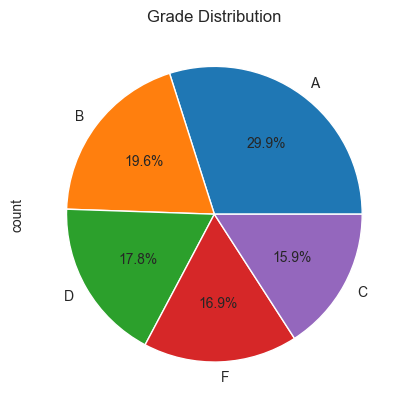

In [12]:
df['grade'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Grade Distribution")
plt.show()

The majority of students received an A (29,9%), followed by B (19,6%) and C (17,8%). Lower grades D (16,9%) and F (15,9%) are also significant, indicating a relatively even spread of performance with a slight skew towards higher grades.


---



The count plot shows how grades are distributed between male and female students. This visualization helps identify potential disparities in academic performance across genders.

Text(0, 0.5, 'Frequency')

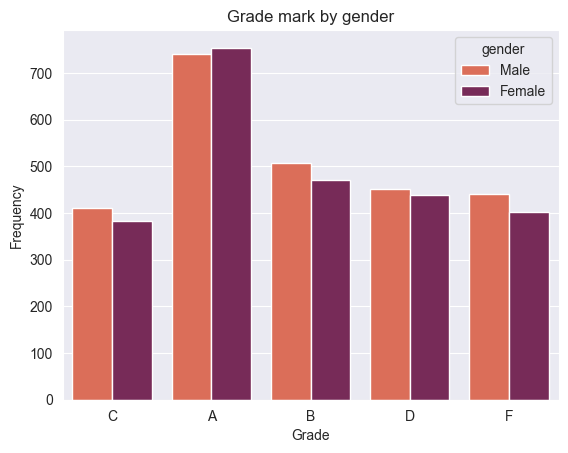

In [13]:
sns.countplot(data = df, x="grade", hue="gender", palette="rocket_r")
plt.title('Grade mark by gender')
plt.xlabel('Grade')
plt.ylabel('Frequency')

Across all grades, male students dominate except for grade "A," where female students slightly outnumber males. This could be influenced by the overall slight majority of male students in the university.

---



This visualization examines the relationship between students' grades and their weekly study hours, with a breakdown by gender. It helps identify whether higher grades correlate with more study time and if there are differences in study habits between male and female students.

Text(0, 0.5, 'Hours per week')

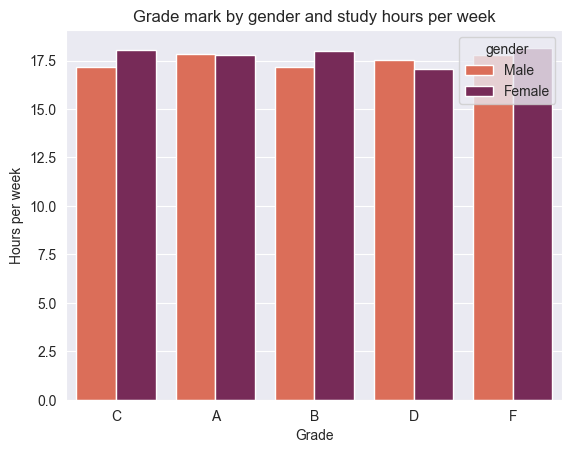

In [14]:
sns.barplot(data = df, x="grade", y="study_hours_per_week", hue="gender", errorbar=None, palette="rocket_r")
plt.title('Grade mark by gender and study hours per week')
plt.xlabel('Grade')
plt.ylabel('Hours per week')

Women generally spend more time studying than men for each grade level, except for grade D, where men study more, and grade A, where both genders dedicate equal time. Interestingly, the **average study time** remains relatively **constant across all grades**. This suggests that factors beyond study hours, such as teaching methods, learning strategies, or external influences, may play a more significant role in determining final grades.

---



This bar plot visualizes the distribution of stress levels (from 1 to 10) among students, segmented by gender. The x-axis represents the stress level, while the y-axis shows the count of students reporting each stress level.

Text(0, 0.5, 'Amount of students')

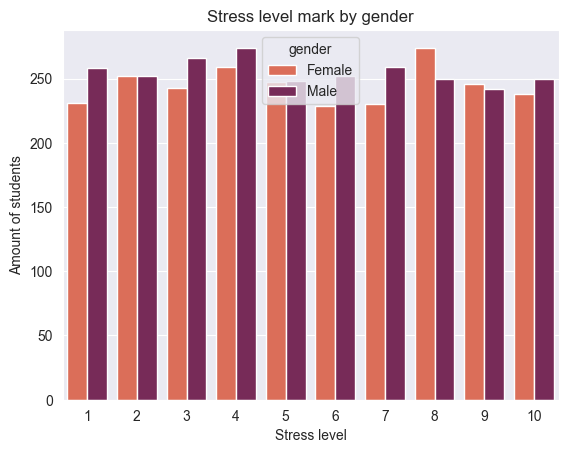

In [15]:
gender_and_stress = df.groupby(["stress_level_1_to_10", "gender"]).size().reset_index(name="count")
sns.barplot(data = gender_and_stress, x="stress_level_1_to_10", y="count", hue="gender", errorbar=None, palette="rocket_r")
plt.title('Stress level mark by gender')
plt.xlabel('Stress level')
plt.ylabel('Amount of students')

Before reaching a stress level of 8, there is a noticeable dominance of male students across most of the stress levels. However, stress level 8 stands out as being more common among female students at this university, with a significant difference in the number of female students reporting this level of stress. Although this gap is noticeable, it is **not substantial enough** to suggest that female students experience **more stress** than their male counterparts.

Furthermore, we observe that male students regain the lead as the stress level **rises towards 10** on the scale, showing a higher number of male students reporting the highest levels of stress.

It is also important to note that at stress level 7, there is a **similar distribution** to level 8, but in the opposite direction: male students slightly outnumber female students, similar to the shift seen at level 8 for women. This suggests a **balancing** act between the genders as stress levels fluctuate.

---



This bar chart illustrates the **average stress level** of students based on their **grade** and **gender**. Each grade category (A, B, C, D, F) is analyzed separately, with stress levels averaged for **male and female students**.

Text(0, 0.5, 'Stress level')

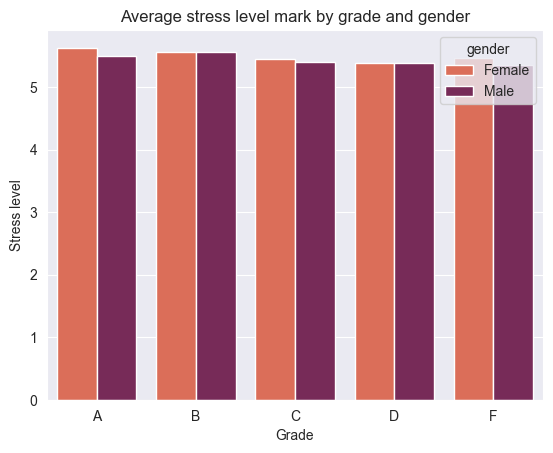

In [16]:
grade_and_stress = df.groupby(["grade", "gender"])["stress_level_1_to_10"].mean().reset_index()
sns.barplot(data = grade_and_stress, x="grade", y="stress_level_1_to_10", hue="gender", errorbar=None, palette="rocket_r")
plt.title('Average stress level mark by grade and gender')
plt.xlabel('Grade')
plt.ylabel('Stress level')

On average, **female** students exhibit slightly **higher stress** levels across all grades. However, the difference is **not significant enough** to suggest major gender disparities.

Interestingly, the most noticeable stress gap for female students appears at **A and F** grades. For A students, this could be linked to **perfectionism** and the **pressure** to maintain top performance. On the other hand, high stress among F students might indicate a stronger fear of **expulsion**, which could be perceived as more alarming for female students compared to male students.

Another notable observation is that students with a **B grade** experience the **highest** average **stress** levels. This might suggest **frustration** or **pressure**, as they are close to achieving an A but fall just short. Meanwhile, C and D students exhibit more balanced stress levels between genders, possibly indicating either lower concern about grades or an adaptation to their academic standing.

---



The pie chart illustrates the proportion of students from different **family income levels**. The distribution helps identify socioeconomic diversity within the university. If a particular income group dominates, it may indicate accessibility challenges or financial barriers for lower-income students.

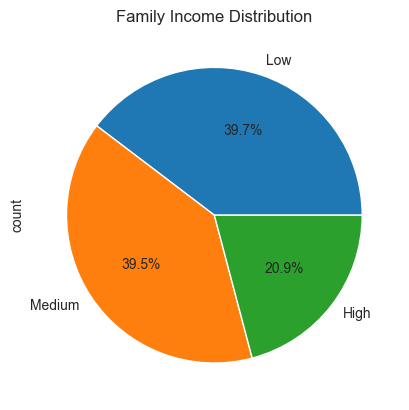

In [17]:
df['family_income_level'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Family Income Distribution")
plt.show()

The group with **medium** and **low-income** levels **predominates**, which could indicate an interesting potential relationship between income and grades, if such a correlation exists. This might suggest that income-related factors could play a role in academic performance within this dataset.

---



This bar plot shows the distribution of grades by family income level, normalized by the percentage of students in each income group.

Text(0.5, 1.0, 'Distribution of Grades by Family Income Level (Normalized)')

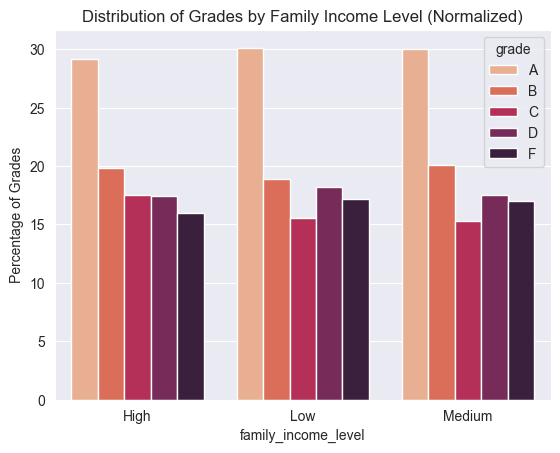

In [18]:
df_counts = df.groupby(["family_income_level", "grade"]).size().reset_index(name="count")

df_counts["percent"] = df_counts.groupby("family_income_level")["count"].transform(lambda x: x / x.sum() * 100)

sns.barplot(data=df_counts, x="family_income_level", y="percent", hue="grade", palette="rocket_r")
plt.ylabel("Percentage of Grades")
plt.title("Distribution of Grades by Family Income Level (Normalized)")

On the graph, we observe a relatively **similar** percentage distribution of students per **grade** within each **financial group**. This indicates that there is **no correlation** between a student's **grade** and their family **income**. One interesting observation is that students from **higher-income** families tend to show **more consistency** in their grade distribution percentages. The **smallest** proportion in this group is students with an **F grade**, while in other groups, the lowest percentage of students is with a **C grade**.












---



On the graph, we see the average **final score** for each **grade** level. The line indicates a general trend across different grades, showing how the final scores vary with grade.

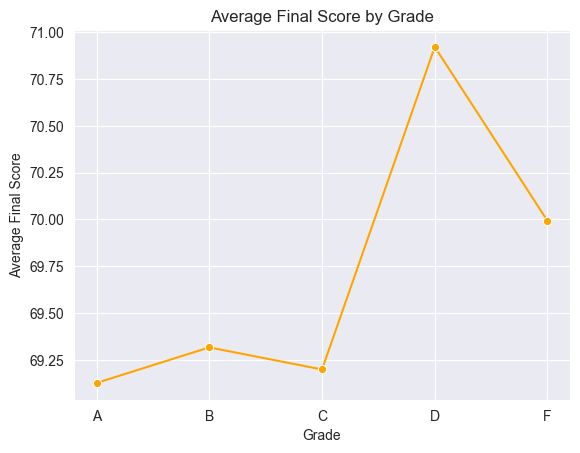

In [19]:
age_grouped = df.groupby("grade")["final_score"].mean().reset_index()

sns.lineplot(data=age_grouped, x="grade", y="final_score", marker="o", color="orange")

plt.xlabel("Grade")
plt.ylabel("Average Final Score")
plt.title("Average Final Score by Grade")
plt.show()

Here, we see a **suspicious** statistic where students with grades **D and F** have higher **final scores** than students with other grades. This is surprising, as we would expect to see a **downward** trend from the highest final score for grade A to the lowest for grade F. This pattern is quite unusual and raises the possibility that there are **additional** subjects or **factors** influencing the final score that are **more significant** than the grades themselves.

---




The bar plot shows the average family **income by department**. It reveals how family income levels vary across different departments in the university, with some departments having higher average incomes compared to others.

C:\Users\galut\AppData\Local\Temp\ipykernel_7552\1621135558.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grouped_income, x="department", y="family_income_level_numeric", palette="rocket_r")


Text(0, 0.5, 'Income level')

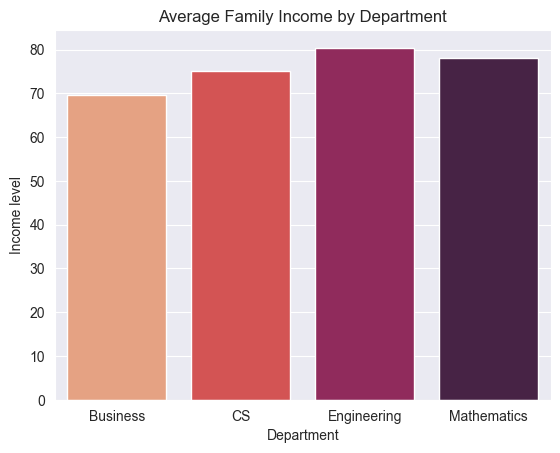

In [20]:
income_mapping = {"Low": 10, "Medium": 50, "High": 250}
df["family_income_level_numeric"] = df["family_income_level"].map(income_mapping)

grouped_income = df.groupby("department")["family_income_level_numeric"].mean().reset_index()

sns.barplot(data=grouped_income, x="department", y="family_income_level_numeric", palette="rocket_r")

plt.title("Average Family Income by Department")
plt.xlabel("Department")
plt.ylabel("Income level")

For ease of understanding, a string-to-numeric mapping with a 1:5 ratio was applied. Based on the graph, we can conclude that **more** students with **high family income** prefer **engineering**, followed by mathematics, computer science, and lastly business.










---



The graph displays the average scores of students in different departments, with lines representing the final score, total score, projects score, and midterm score. Each department has its own data points for these four types of scores, allowing us to compare how each department performs across these categories. The lines help visualize trends and show the relative strengths of each department in terms of student performance.

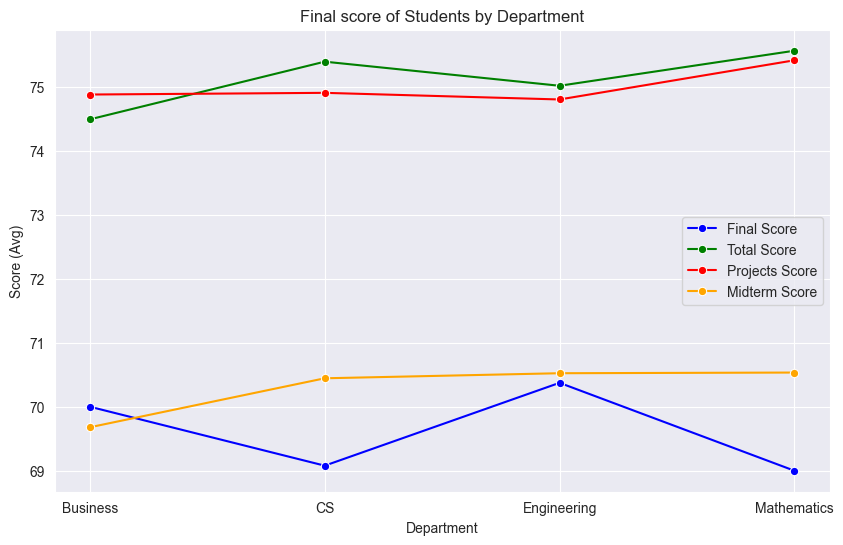

In [21]:
df_department_score = df.groupby("department")[["final_score", "total_score", "projects_score", "midterm_score"]].mean().reset_index()
plt.figure(figsize=(10, 6))

sns.lineplot(data=df_department_score, x="department", y="final_score", color="blue", marker="o", label="Final Score")
sns.lineplot(data=df_department_score, x="department", y="total_score", color="green", marker="o", label="Total Score")
sns.lineplot(data=df_department_score, x="department", y="projects_score", color="red", marker="o", label="Projects Score")
sns.lineplot(data=df_department_score, x="department", y="midterm_score", color="orange", marker="o", label="Midterm Score")

plt.title("Final score of Students by Department")
plt.xlabel("Department")
plt.ylabel("Score (Avg)")

plt.show()

It is evident that for all departments, there is a trend of **lower final scores** regardless of **project and total scores**. It seems that **final scores** are more closely **correlated** with **midterm scores** than with other metrics. However, in some departments, there is even an **inverse** correlation. This could suggest that students are evaluated on **additional** **criteria** or metrics that are **not available** to us in the dataset, which may influence the final scores.

---



The graph shows the relationship between the number of study hours per week and the average final score.

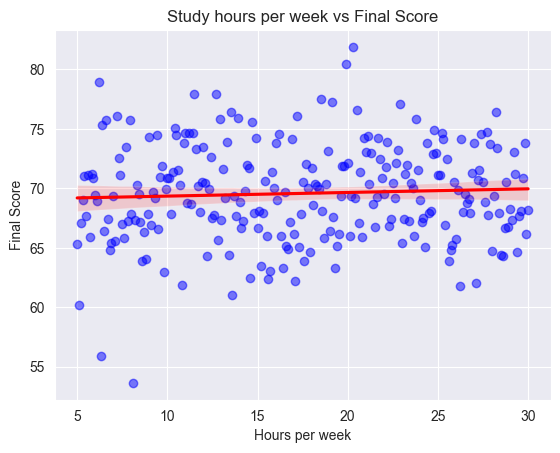

In [24]:
df_grouped = df.groupby("study_hours_per_week")["final_score"].mean().reset_index()

sns.regplot(data=df_grouped, x="study_hours_per_week", y="final_score", scatter_kws={"color": "blue", "alpha": 0.5}, line_kws={"color": "red"})

plt.title("Study hours per week vs Final Score")
plt.xlabel("Hours per week")
plt.ylabel("Final Score")

plt.show()

On this graph, we can observe that regardless of the number of hours spent on studying, the **average final score** remains at a **similar level**. In fact, it slightly **decreases** as the weekly study hours **increase**. The **best** results are shown in the range of about **20 hours** per week. The **lowest** results, as expected, are between **5 and 10** hours per week. However, in this same range, there are **unusually** high values, such as an average of around **80 points**, which is quite uncommon in general statistics.

---



On this graph, we can see the relationship between sleep hours per night and the average final score.

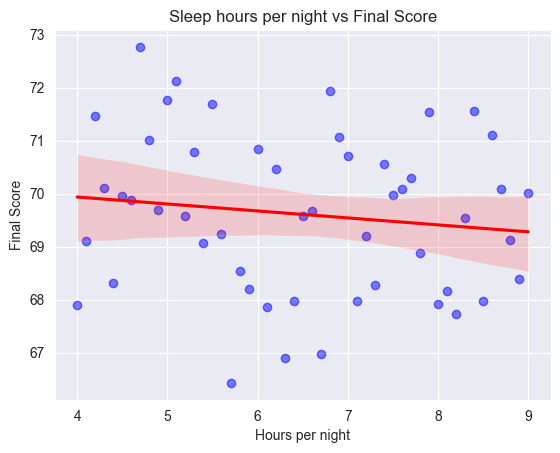

In [28]:
df_grouped = df.groupby("sleep_hours_per_night")["final_score"].mean().reset_index()

sns.regplot(data=df_grouped, x="sleep_hours_per_night", y="final_score", scatter_kws={"color": "blue", "alpha": 0.5}, line_kws={"color": "red"})
plt.title("Sleep hours per night vs Final Score")
plt.xlabel("Hours per night")
plt.ylabel("Final Score")

plt.show()

Here, we observe an trend of a **decrease** in final scores with an **increase** in sleep hours among students, which was **not expected**. It is worth noting that the best performance was seen in the **4-5 hours** of sleep segment, where there is an absence of low scores and a significant presence of scores close to the maximum. The worst performance was observed in the **5:30 - 7** hours of sleep range, where the lowest average scores were present.

---



This heatmap shows the correlation between sleep hours per night and study hours per week.

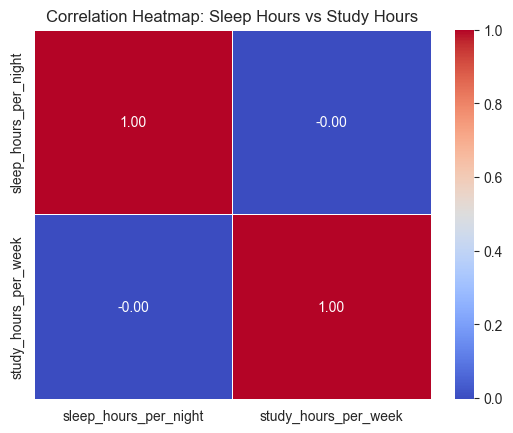

In [29]:
corr = df[["sleep_hours_per_night", "study_hours_per_week"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Sleep Hours vs Study Hours")

plt.show()

As we can see, there is **no correlation**, which means that the amount of sleep does not correlate with the number of hours dedicated to studying.


---



# Conclusion

Based on the data analysis, there was no evidence of gender or income-based discrimination, nor was there any intentional deterioration of grades for specific groups of students based on any characteristics. The overall well-being of students appears satisfactory, as the stress levels remain roughly the same regardless of the grade.

## Key Observations
There are certain evaluation systems in place that seem to have a greater influence on the final scores than others present in the dataset. There is no direct correlation between grade and final score, which is somewhat misleading. This discrepancy suggests that there may be other factors affecting the final score that are not fully captured in the data.

## Recommendation
It is advisable to review the grading system in more detail. Gather data on all possible grading metrics, and identify the most significant factors influencing the final scores.